# 03 Functional Coupling From Correlation

Standalone layer that derives functional coupling matrices from the saved empirical correlation matrix.

In [1]:
from pathlib import Path
import sys

module_dir = Path.cwd()
if not (module_dir / "functional_analysis_utils.py").exists() and (Path.cwd() / "funconn-analysis" / "functional_analysis_utils.py").exists():
    module_dir = Path.cwd() / "funconn-analysis"
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from functional_analysis_utils import (
    RUN_DATE,
    eigenspectrum_desc,
    eigenspectrum_summary,
    fit_power_law_positive,
    functional_paths,
    matrix_abs_limit,
    plot_power_law_fit,
    plot_positive_eigenvalues,
    plot_subsampled_eigenspectrum,
    read_matrix_csv,
    save_eigenspectrum_csv,
    save_matrix,
    sorted_diagonal_spectrum,
)

sns.set_theme(style="white", context="notebook")
paths = functional_paths()
CORR_DIR = paths["correlation"]
EIGEN_DIR = paths["coupling_eigen"]
LAYER_DIR = paths["layer_annotation"]
print("Functional output:", paths["functional_base"])


Functional output: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03


In [2]:
K_FRACTIONS = [0.125, 0.25, 0.5, 0.75]
N_ITER = 50
SEED = 1043

corr_df = read_matrix_csv(CORR_DIR / "V1_col_7_4_activity_correlation_matrix.csv")
unit_ids = corr_df.index.astype(int)
functional_corr_df = corr_df.copy().astype(float)

W_func_df = functional_corr_df.copy()
np.fill_diagonal(W_func_df.values, 0.0)
functional_network_csv = EIGEN_DIR / "V1_col_7_4_functional_network_offdiag_matrix.csv"
save_matrix(W_func_df, functional_network_csv)

functional_coupling = W_func_df.T @ W_func_df
diag_mean = np.trace(functional_coupling.to_numpy(dtype=float)) / functional_coupling.shape[0]
if not np.isfinite(diag_mean) or diag_mean <= 0:
    raise ValueError("Functional coupling trace normalization denominator is invalid.")
functional_coupling = functional_coupling / diag_mean
functional_coupling.index = unit_ids
functional_coupling.columns = unit_ids
functional_coupling_matrix = functional_coupling.to_numpy(dtype=float)
functional_coupling_csv = EIGEN_DIR / "V1_col_7_4_functional_coupling_correlation_matrix.csv"
save_matrix(functional_coupling, functional_coupling_csv)

print("Functional network shape:", W_func_df.shape)
print("Functional coupling Tr(C)/N:", np.trace(functional_coupling_matrix) / functional_coupling_matrix.shape[0])


Functional network shape: (126, 126)
Functional coupling Tr(C)/N: 1.0000000000000002


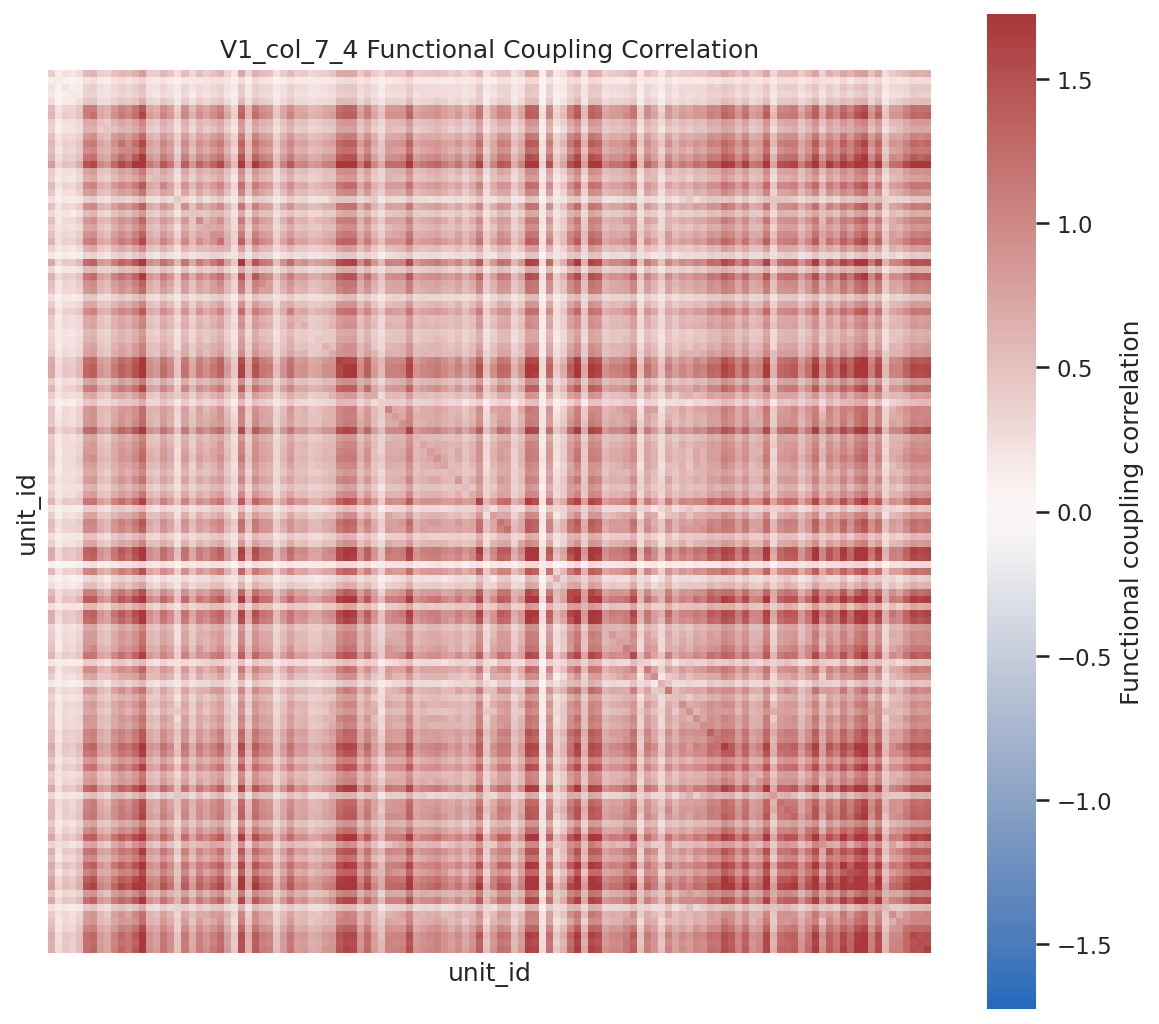

Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_coupling_correlation_heatmap.png


In [3]:
limit = matrix_abs_limit(functional_coupling_matrix)
fig, ax = plt.subplots(figsize=(8, 7), dpi=150)
sns.heatmap(functional_coupling, cmap="vlag", center=0, vmin=-limit, vmax=limit, xticklabels=False, yticklabels=False, square=True, cbar_kws={"label": "Functional coupling correlation"}, ax=ax)
ax.set_title("V1_col_7_4 Functional Coupling Correlation")
ax.set_xlabel("unit_id")
ax.set_ylabel("unit_id")
fig.tight_layout()
heatmap_path = EIGEN_DIR / "V1_col_7_4_functional_coupling_correlation_heatmap.png"
fig.savefig(heatmap_path, bbox_inches="tight")
plt.show()
print("Saved:", heatmap_path)


Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_correlation_eigenspectrum.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_coupling_correlation_eigenspectrum.csv


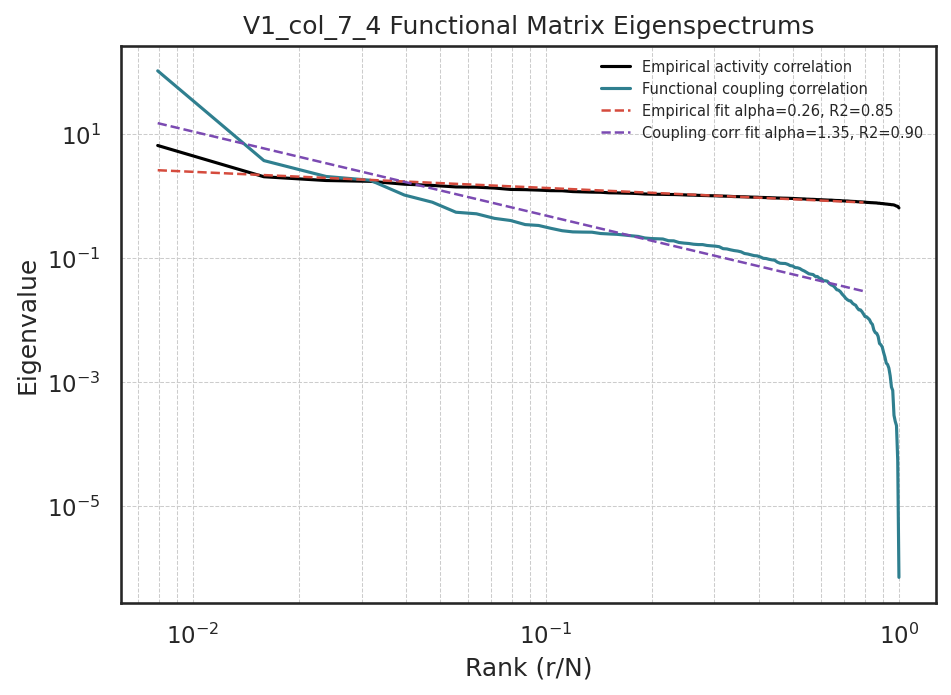

Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_correlation_and_coupling_eigenspectrums.png


In [4]:
corr_matrix = corr_df.to_numpy(dtype=float)
corr_evals = eigenspectrum_desc(corr_matrix)
functional_coupling_evals = eigenspectrum_desc(functional_coupling_matrix)
fit_corr = fit_power_law_positive(corr_evals, num_top_eigenvalues=100)
fit_functional_coupling = fit_power_law_positive(functional_coupling_evals, num_top_eigenvalues=100)

corr_eigenspectrum_df = save_eigenspectrum_csv(corr_evals, EIGEN_DIR / "V1_col_7_4_activity_correlation_eigenspectrum.csv")
functional_coupling_eigenspectrum_df = save_eigenspectrum_csv(functional_coupling_evals, EIGEN_DIR / "V1_col_7_4_functional_coupling_correlation_eigenspectrum.csv")

fig, ax = plt.subplots(figsize=(6.5, 4.8), dpi=150)
plot_positive_eigenvalues(ax, corr_evals, "Empirical activity correlation", "black")
plot_positive_eigenvalues(ax, functional_coupling_evals, "Functional coupling correlation", "#2f7f8f")
plot_power_law_fit(ax, fit_corr, "Empirical fit", "#d54b3d")
plot_power_law_fit(ax, fit_functional_coupling, "Coupling corr fit", "#7b4ab2")
ax.set_xlabel("Rank (r/N)")
ax.set_ylabel("Eigenvalue")
ax.set_title("V1_col_7_4 Functional Matrix Eigenspectrums")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.legend(frameon=False, fontsize=7)
fig.tight_layout()
png_path = EIGEN_DIR / "V1_col_7_4_functional_correlation_and_coupling_eigenspectrums.png"
fig.savefig(png_path, bbox_inches="tight")
plt.show()
print("Saved:", png_path)


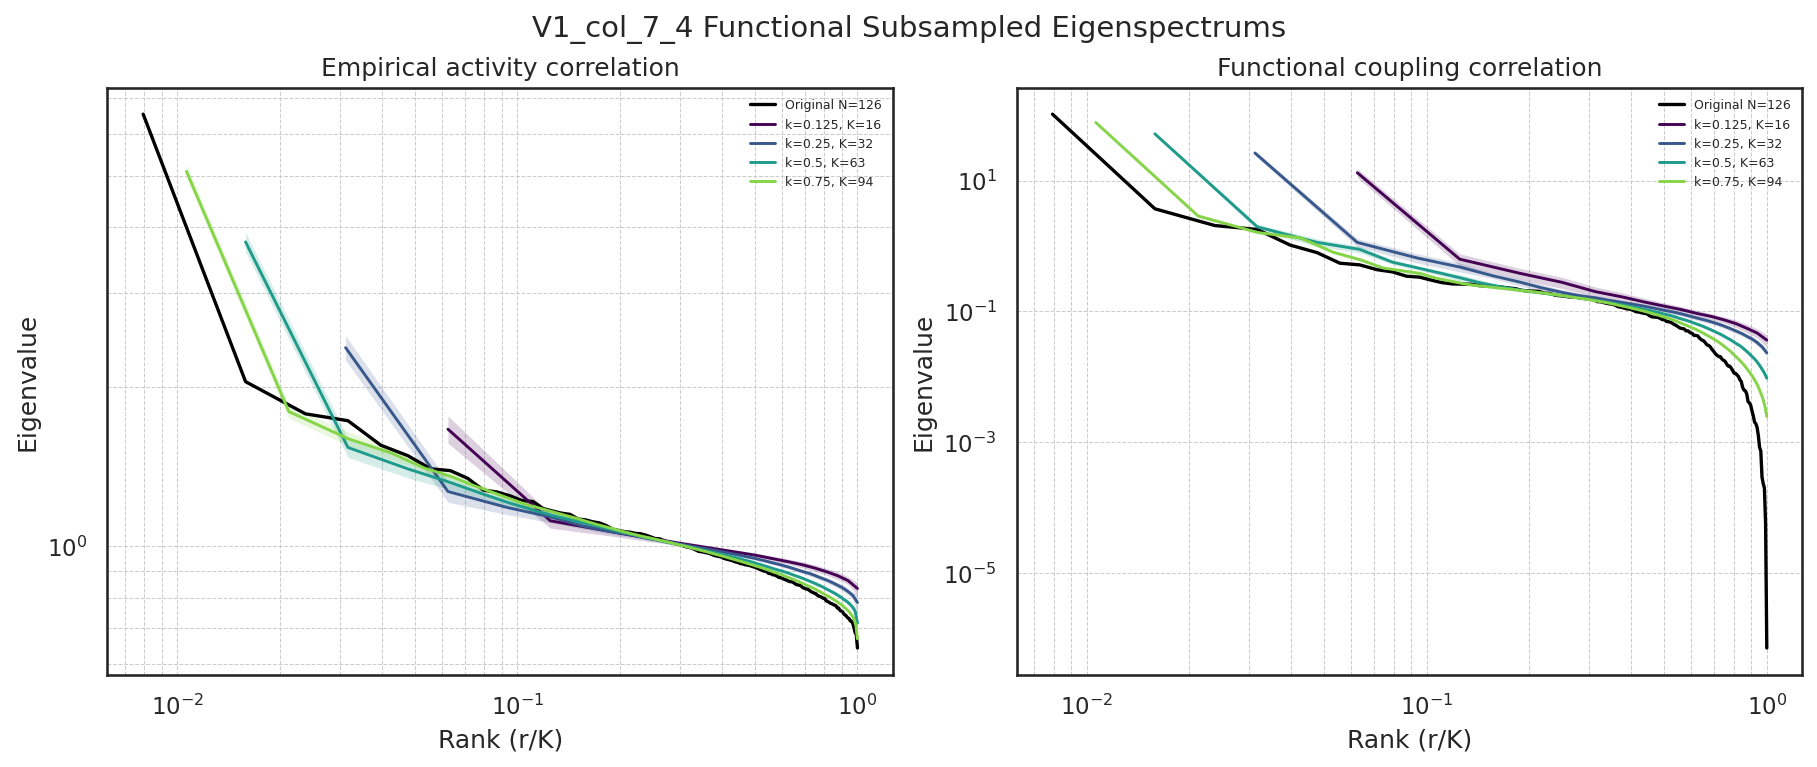

Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_subsampled_eigenspectrums.png
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_correlation_subsampled_eigenspectrum.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_coupling_correlation_subsampled_eigenspectrum.csv


,rank,rank_normalized,eigenvalue
0,1,0.007937,6.524891
1,2,0.015873,2.043231
2,3,0.023810,1.776919
3,4,0.031746,1.724752
4,5,0.039683,1.550314
5,6,0.047619,1.481808
6,7,0.055556,1.400025
7,8,0.063492,1.388537
8,9,0.071429,1.343001
9,10,0.079365,1.276059


,rank,rank_normalized,eigenvalue
0,1,0.007937,104.386578
1,2,0.015873,3.721844
2,3,0.023810,2.064184
3,4,0.031746,1.796289
4,5,0.039683,1.035662
5,6,0.047619,0.793863
6,7,0.055556,0.547232
7,8,0.063492,0.516252
8,9,0.071429,0.435795
9,10,0.079365,0.402336


,k_fraction,K,rank,rank_normalized,mean_eigenvalue,std_eigenvalue
0,0.125,16,1,0.0625,13.265976,2.058639
1,0.125,16,2,0.1250,0.630766,0.131666
2,0.125,16,3,0.1875,0.384278,0.073035
3,0.125,16,4,0.2500,0.278810,0.054753
4,0.125,16,5,0.3125,0.201548,0.036036


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150, constrained_layout=True)
fig.suptitle("V1_col_7_4 Functional Subsampled Eigenspectrums", fontsize=14)

corr_subsampled_df = plot_subsampled_eigenspectrum(axes[0], corr_matrix, "Empirical activity correlation", K_FRACTIONS, n_iter=N_ITER, seed=SEED)
functional_coupling_subsampled_df = plot_subsampled_eigenspectrum(axes[1], functional_coupling_matrix, "Functional coupling correlation", K_FRACTIONS, n_iter=N_ITER, seed=SEED + 1000)

png_path = EIGEN_DIR / "V1_col_7_4_functional_subsampled_eigenspectrums.png"
fig.savefig(png_path, bbox_inches="tight")
plt.show()
print("Saved:", png_path)

corr_subsampled_csv = EIGEN_DIR / "V1_col_7_4_activity_correlation_subsampled_eigenspectrum.csv"
functional_coupling_subsampled_csv = EIGEN_DIR / "V1_col_7_4_functional_coupling_correlation_subsampled_eigenspectrum.csv"
corr_subsampled_df.to_csv(corr_subsampled_csv, index=False)
functional_coupling_subsampled_df.to_csv(functional_coupling_subsampled_csv, index=False)
print("Saved:", corr_subsampled_csv)
print("Saved:", functional_coupling_subsampled_csv)
display(corr_eigenspectrum_df.head(10))
display(functional_coupling_eigenspectrum_df.head(10))
display(functional_coupling_subsampled_df.head())
